Loading MNIST...
MNISTNet(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)
Total parameters: 109,386
Epoch  1 | Loss: 0.4012 | Train: 0.8829 | Test: 0.9481
Epoch  2 | Loss: 0.1767 | Train: 0.9476 | Test: 0.9627
Epoch  3 | Loss: 0.1318 | Train: 0.9606 | Test: 0.9693
Epoch  4 | Loss: 0.1052 | Train: 0.9680 | Test: 0.9717
Epoch  5 | Loss: 0.0935 | Train: 0.9711 | Test: 0.9736
Epoch  6 | Loss: 0.0848 | Train: 0.9742 | Test: 0.9728
Epoch  7 | Loss: 0.0763 | Train: 0.9768 | Test: 0.9728
Epoch  8 | Loss: 0.0678 | Train: 0.9793 | Test: 0.9746
Epoch  9 | Loss: 0.0632 | Train: 0.9802 | Test: 0.9751
Epoch 10 | Loss: 0.0559 | Train: 0.9821 | Test: 0.9759
Epoch 11 | Loss: 0.0562 | Train: 0.9817 | Test: 0.9751
Epoch 12 | Loss: 0.0518 | Train: 0.9826 | Test: 0.9766
Epoch 13 | Loss: 0.0484 | Train: 0.9846 | Test: 0.9754
Epoc

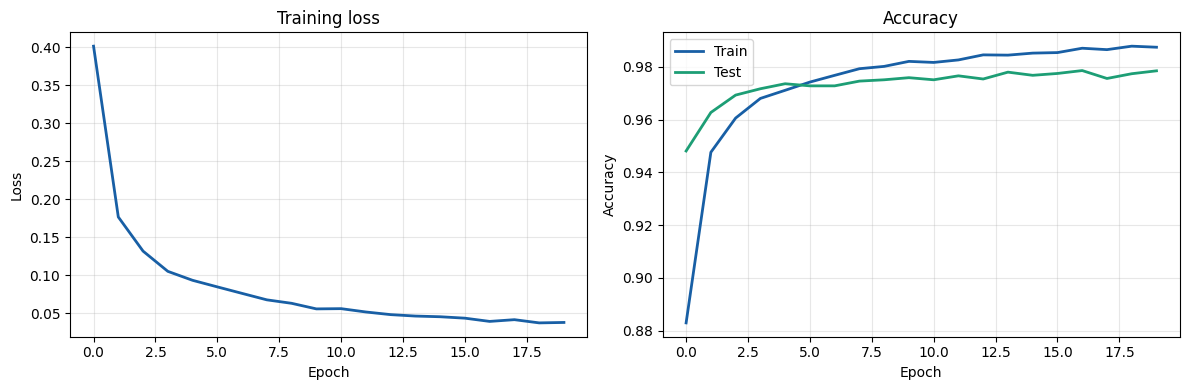


Final test accuracy: 0.9785


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

#  Loading data 
print("Loading MNIST...")
mnist   = fetch_openml('mnist_784', version=1, as_frame=False)
X       = mnist.data.astype(np.float32) / 255.0
y       = mnist.target.astype(np.int64)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=10000, random_state=42
)

#  Converting numpy to PyTorch tensors
X_tr_t = torch.from_numpy(X_tr)
y_tr_t = torch.from_numpy(y_tr)
X_te_t = torch.from_numpy(X_te)
y_te_t = torch.from_numpy(y_te)

# DataLoader handles batching and shuffling automatically
train_ds     = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)


#  Define network
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.dropout = nn.Dropout(0.2)  # randomly zero 20% of neurons prevents overfitting

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


model     = MNISTNet()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")


#  Training loop
def train_epoch(model, loader, criterion, optimizer):
    model.train()   # training mode — dropout active
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in loader:
        
        y_pred = model(X_batch)              # 1. forward
        loss   = criterion(y_pred, y_batch)  # 2. loss
        optimizer.zero_grad()                # 3. clear gradients
        loss.backward()                      # 4. backward
        optimizer.step()                     # 5. update

        total_loss += loss.item()
        correct    += (y_pred.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / len(loader), correct / total


def evaluate(model, X, y):
    model.eval()   
    with torch.no_grad():   
        preds = model(X).argmax(1)
    return (preds == y).float().mean().item()


#  Run training
losses, train_accs, test_accs = [], [], []

for epoch in range(20):
    loss, train_acc = train_epoch(model, train_loader,
                                   criterion, optimizer)
    test_acc = evaluate(model, X_te_t, y_te_t)

    losses.append(loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1:2d} | Loss: {loss:.4f} "
          f"| Train: {train_acc:.4f} | Test: {test_acc:.4f}")


#  Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses, color='#185FA5', linewidth=2)
ax1.set_title('Training loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

ax2.plot(train_accs, label='Train', color='#185FA5', linewidth=2)
ax2.plot(test_accs,  label='Test',  color='#1D9E75', linewidth=2)
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal test accuracy: {test_accs[-1]:.4f}")

In [2]:
# Save
torch.save(model.state_dict(), 'mnist_model.pth')
print("Model saved!")

# Load later
model_loaded = MNISTNet()
model_loaded.load_state_dict(torch.load('mnist_model.pth'))
model_loaded.eval()

# Predict on a single image
single_image = X_te_t[0].unsqueeze(0)   # add batch dim → (1, 784)
with torch.no_grad():
    output = model_loaded(single_image)
    pred   = output.argmax().item()
print(f"Predicted: {pred}, True: {y_te[0]}")

Model saved!
Predicted: 8, True: 8
